# dQdV peak analysis

In [1]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# First, plot the dQ/dV curves to identify peaks of interest

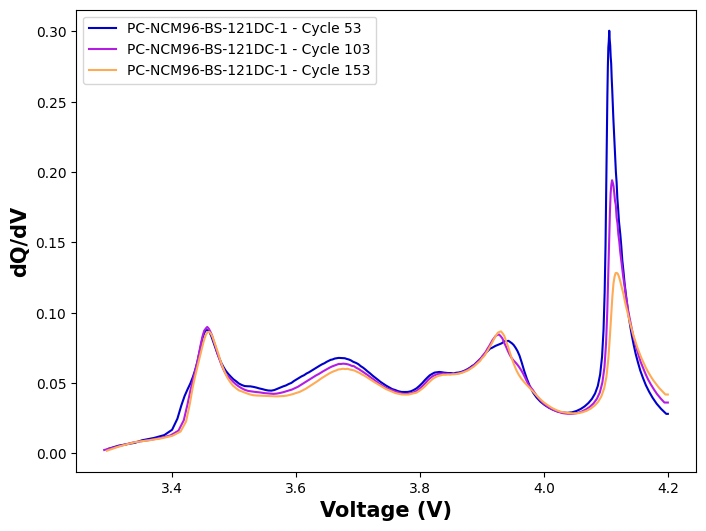

In [2]:
test_files = glob.glob(r'C:\Users\jake.tjalkens\OneDrive - Redwood Materials\Documents\dQdV analysis\dQdV anlaysis files\*.xlsx')

fig, ax = plt.subplots(figsize=(8,6))

for test in test_files:
    df = pd.read_excel(test, sheet_name=1)
    label = os.path.splitext(os.path.basename(test))[0]
    parts = label.split('_')
    label = parts[0]
    
    df['dQ/dV'] = pd.to_numeric(df['dQ/dV'], errors='coerce') # convert to numeric to handle blanks and strings easily
    df = df.dropna(subset=['dQ/dV']) # drop entire rows where the dQ/dV is empty - subset does this based off the specified column
    df = df[df['Step Index'] == 32] # only look at step 32 (slow current rate - near OCV)
    df = df[df['Cycle Index'] > 30] # only extract dQ/dV from state of health cycles
    
    cycles = sorted(df['Cycle Index'].unique())
    colors = plt.cm.gnuplot2(np.linspace(0.2, 0.75, len(cycles)))
    
    for i, cycle in enumerate(cycles):
        df_cycle = df[df['Cycle Index'] == cycle]
        
        x = df_cycle['Voltage (V)']
        y = df_cycle['dQ/dV']
        
        ax.plot(x, y, color=colors[i], label=f'{label} - Cycle {cycle}')
        
ax.set_xlabel('Voltage (V)', fontsize = 15, fontweight = 'bold')
ax.set_ylabel('dQ/dV', fontsize = 15, fontweight = 'bold')
ax.legend()
plt.savefig(f'dQdV-{label}', dpi=300)
plt.show()

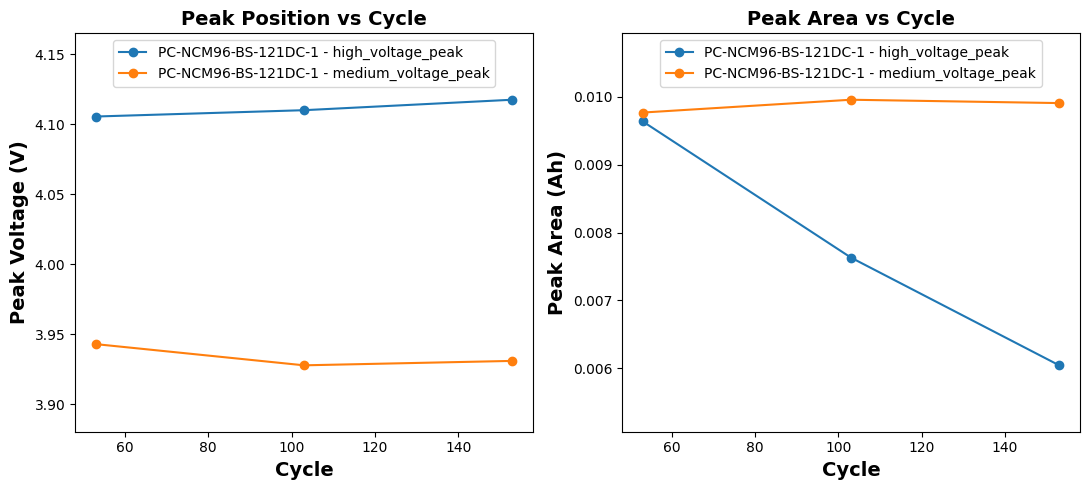

                Sample  Cycle            Peak Name  Peak Voltage  Peak Height  \
0  PC-NCM96-BS-121DC-1     53    high_voltage_peak      4.105471     0.300475   
1  PC-NCM96-BS-121DC-1     53  medium_voltage_peak      3.942835     0.080063   
2  PC-NCM96-BS-121DC-1    103    high_voltage_peak      4.109992     0.194237   
3  PC-NCM96-BS-121DC-1    103  medium_voltage_peak      3.927697     0.084530   
4  PC-NCM96-BS-121DC-1    153    high_voltage_peak      4.117465     0.128348   
5  PC-NCM96-BS-121DC-1    153  medium_voltage_peak      3.930859     0.086760   

   Peak Width  Peak Area  
0    0.077196   0.009635  
1    0.175753   0.009766  
2    0.074521   0.007631  
3    0.185276   0.009955  
4    0.075283   0.006045  
5    0.186008   0.009905  


In [4]:
# folder containing excel data files
test_files = glob.glob(
    r'C:\Users\jake.tjalkens\OneDrive - Redwood Materials\Documents\dQdV analysis\dQdV anlaysis files\*.xlsx'
    )

# Arbin step - we want SOH charge step because it is low C-rate and therefore not too far from OCV
target_step = 32

# only include full SOH charges - exclude lower cycles that hit step 32 briefly
min_cycle = 40

# peak_finder needs x-axis windows (voltage windows) to find peaks - can enter as many peaks as are interesting to user
peak_windows = {
    'high_voltage_peak': (4.08, 4.16),
    'medium_voltage_peak': (3.86, 4.1)
}

# peak detection controls to differentiate by peak size and width to avoid falsely choosing data noise as a peak
min_prominence = 0.005
min_width = 2

# ======== TRACKER FUNCTION ========

def peak_tracker(df_cycle, vmin, vmax, cycle_number, sample_name, peak_name):
    # df_cycle : data for ONE cycle containing voltage and dQ/dV columns
    # vmin, vmax : voltage limits for the peak search
    # cycle_number : label the cycle number for bookkeeping purposes
    # sample_name : label the sample being looked at for bookkeping
    # peak_name : know which peak we're looking at

    # extract correct columns
    x = df_cycle['Voltage (V)'].to_numpy()
    y = df_cycle['dQ/dV'].to_numpy()

    # sort both x and y to lock in correct data pairs by index
    sort_idx = np.argsort(x)
    x = x[sort_idx]
    y = y[sort_idx]

    # create a boolean mask that only keeps data inside the current voltage window
    mask = (x >= vmin ) & (x <= vmax )
    xwin = x[mask]
    ywin = y[mask]

    # if the selected window has too few points, skip it
    if len(xwin) < 10:
        return None

    # find the peaks within the windows: find_peaks returns 
    # 1: indices of the peaks
    # 2: properties such as height, width, prominence
    peaks, properties = find_peaks(ywin, prominence=min_prominence, width=min_width)

    if len(peaks) == 0:
        return None

    # if more than one peak inside window -> choose the tallest one
    peak_idx = np.argmax(ywin[peaks])
    peak_array_idx = peaks[peak_idx]

    # peak position, height, and prominence
    peak_voltage = xwin[peak_array_idx]
    peak_height = ywin[peak_array_idx]
    peak_prominence = properties['prominences'][peak_idx]

    # extract the base bounds of the peak for integration
    left_base_idx = properties['left_bases'][peak_idx]
    right_base_idx = properties['right_bases'][peak_idx]

    # calculate base width in voltage
    left_voltage = xwin[left_base_idx]
    right_voltage = xwin[right_base_idx]
    peak_width = right_voltage - left_voltage

    # integrate across the peak region, base to base
    x_peak = xwin[left_base_idx:right_base_idx]
    y_peak = ywin[left_base_idx:right_base_idx]
    peak_area = np.trapezoid(y_peak, x_peak)

    result = {
        'Sample': sample_name,
        'Cycle': cycle_number,
        'Peak Name': peak_name,
        'Peak Voltage': peak_voltage,
        'Peak Height': peak_height,
        'Peak Width': peak_width,
        'Peak Area': peak_area
    }

    return result

# ======== analysis loop ========
results = []

for test in test_files:
    
    df = pd.read_excel(test, sheet_name=1)

    # sample name
    sample_name = os.path.splitext(os.path.basename(test))[0]
    parts = sample_name.split('_')
    sample_name = parts[0]

    # clean data and extract appropriate segments from dataframe
    df['dQ/dV'] = pd.to_numeric(df['dQ/dV'], errors='coerce')
    df = df.dropna(subset=['dQ/dV'])
    df = df[df['Step Index'] == target_step]
    df = df[df['Cycle Index'] > min_cycle]

    # separate the unique SOH cycles from each other
    cycles = sorted(df['Cycle Index'].unique())

    # analyze each cycle separately
    for cycle in cycles:
        
        # subset of the data that only includes current cycle
        df_cycle = df[df['Cycle Index'] == cycle]

        for peak_name, (vmin, vmax) in peak_windows.items():
            result = peak_tracker(
                df_cycle=df_cycle,
                vmin=vmin,
                vmax=vmax,
                cycle_number=cycle,
                sample_name=sample_name,
                peak_name=peak_name
                )

            if result is not None:
                results.append(result)


# ======== plotting & final results ========
results_df = pd.DataFrame(results)

# plot peak voltage vs cycle 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (11,5))

# create groups within dataframe that are split up by sample 
for (sample, peak_name), group in results_df.groupby(['Sample', 'Peak Name']):
    group = group.sort_values('Cycle')
    
    ax1.plot(group['Cycle'], group['Peak Voltage'], marker='o', label=f'{sample} - {peak_name}')

ax1.set_xlabel('Cycle', fontsize=14, fontweight='bold')
ax1.set_ylabel('Peak Voltage (V)', fontsize=14, fontweight='bold')
ax1.set_title('Peak Position vs Cycle', fontsize=14, fontweight='bold')
ax1.margins(y=0.25)
ax1.legend(loc='upper center')

for (sample, peak_name), group in results_df.groupby(['Sample', 'Peak Name']):
    group = group.sort_values('Cycle')
    
    ax2.plot(group['Cycle'], group['Peak Area'], marker='o', label=f'{sample} - {peak_name}')
    
ax2.set_xlabel('Cycle', fontsize=14, fontweight='bold')
ax2.set_ylabel('Peak Area (Ah)', fontsize=14, fontweight='bold')
ax2.set_title('Peak Area vs Cycle', fontsize=14, fontweight='bold')
ax2.margins(y=0.25)
ax2.legend(loc='upper center')

plt.tight_layout()
plt.show()

print(results_df)